In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

# Make the plots look publication-ready
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5
})

# Define the paths to our compiled grid
CATALOG_PATH = "../outputs/master_grid_catalog.csv"
DATA_PATH = "../outputs/master_grid_data.h5"

In [2]:
import pickle
import pandas as pd
from pathlib import Path

# Point this to your grid directory
grid_dir = Path("../outputs/grid_run") 
pkl_files = list(grid_dir.glob("**/*.pkl"))

if not pkl_files:
    print("❌ No .pkl files found in that directory!")
else:
    # Grab the first file for inspection
    sample_file = pkl_files[10]
    print(f"📂 Opening file: {sample_file}\n" + "="*50)
    
    with open(sample_file, 'rb') as f:
        data = pickle.load(f)
        
    print("🔑 TOP-LEVEL KEYS:")
    print(list(data.keys()), "\n")
    
    # Loop through the dictionary and print the contents
    for key, value in data.items():
        if isinstance(value, pd.DataFrame):
            print(f"📊 COLUMNS IN DATAFRAME '{key}':")
            # Print columns neatly
            cols = value.columns.tolist()
            print(cols, "\n")
            
        elif isinstance(value, dict):
            print(f"📁 KEYS IN NESTED DICTIONARY '{key}':")
            # Print the first few keys so it doesn't flood the output
            keys = list(value.keys())
            print(keys, "\n")

📂 Opening file: ../outputs/grid_run/target/M_1.000_Tirr_100.0_Tint_838.7_Met_-2.00_Core_10.0_fsed_3.0_kzz_8.0_sigma_0.00.pkl
🔑 TOP-LEVEL KEYS:
['status', 'timestamp', 'parameters', 'iterations', 'profile', 'atmosphere_raw', 'interior_raw', 'photometry'] 

📁 KEYS IN NESTED DICTIONARY 'parameters':
['iron_fraction', 'debug', 'mass', 'T_int', 'T_irr', 'Met', 'core_mass_earth', 'f_sed', 'kzz', 'g_1bar', 'atmosphere_parameters', 'paths', 'retrieval_parameters', 'z_base', 'Y_ratio', 'T_int_input_dial', 'true_mass_Mjup', 'p_link_bar'] 

📊 COLUMNS IN DATAFRAME 'profile':
['Pressure_Pa', 'Pressure_bar', 'Radius_m', 'Temperature_K', 'Density_kgm3', 'Gravity_ms2', 'MolarMass_kgmol'] 

📊 COLUMNS IN DATAFRAME 'atmosphere_raw':
['/model_parameters/atmosphere/eddy_mode', '/model_parameters/clouds/fraction', '/model_parameters/clouds/mode', '/model_parameters/clouds/particle_density/H2O', '/model_parameters/clouds/particle_density/KCl', '/model_parameters/clouds/particle_radius/H2O', '/model_parameter

In [3]:
# Load the catalog
catalog = pd.read_csv(CATALOG_PATH)

# Display some high-level stats
total_models = len(catalog)
converged = len(catalog[catalog['status'] == 'target_reached'])

print(f"📦 Total Models in Grid: {total_models}")
print(f"✅ Converged Models: {converged} ({(converged/total_models)*100:.1f}%)")
print("-" * 50)

# Show the first 5 rows to see what parameters we have to play with
display(catalog.head())

📦 Total Models in Grid: 6623
✅ Converged Models: 1123 (17.0%)
--------------------------------------------------


,model_id,status,target_mass_Mjup,R_1bar_Rjup,true_mass_Mjup,T_int_dial_K,T_int_true_K,T_irr_K,metallicity,core_mass_Me,...,GAIA_GAIA3.G_flux_Wm2um,GAIA_GAIA3.G_flux_Jy,GAIA_GAIA3.Gbp_flux_Wm2um,GAIA_GAIA3.Gbp_flux_Jy,GAIA_GAIA3.Grp_flux_Wm2um,GAIA_GAIA3.Grp_flux_Jy,TESS_TESS.Red_flux_Wm2um,TESS_TESS.Red_flux_Jy,Kepler_Kepler.K_flux_Wm2um,Kepler_Kepler.K_flux_Jy
0,model_00000,crashed,0.1,NaN,NaN,100.0,100.0,500.0,0.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,model_00001,crashed,0.1,NaN,NaN,100.0,100.0,500.0,1.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,model_00002,crashed,0.3,NaN,NaN,200.0,200.0,500.0,1.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,model_00003,crashed,1.0,NaN,NaN,500.0,500.0,100.0,-1.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,model_00004,crashed,1.0,NaN,NaN,200.0,200.0,1000.0,0.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import h5py
import os

def print_hdf5_tree(h5_path, max_models_to_show=1):
    """Prints a beautifully formatted tree of the HDF5 file structure."""
    
    if not os.path.exists(h5_path):
        print(f"❌ File not found: {h5_path}")
        return
        
    file_size_mb = os.path.getsize(h5_path) / (1024 * 1024)
    print(f"🗄️ HDF5 File: {h5_path} ({file_size_mb:.1f} MB)")
    print("=" * 60)
    
    with h5py.File(h5_path, "r") as h5f:
        model_keys = list(h5f.keys())
        print(f"📦 Total Models Stored: {len(model_keys)}\n")
        
        # We only want to print the deep structure for the first few models so we don't spam the notebook
        for i, model_id in enumerate(model_keys[:max_models_to_show]):
            print(f"🪐 {model_id}/")
            
            # A recursive function to walk through the folders and print them like a tree
            def print_structure(name, obj):
                # Calculate indentation based on how deep we are in the folders
                depth = name.count('/') + 1 
                indent = "    " * depth
                item_name = name.split('/')[-1]
                
                if isinstance(obj, h5py.Group):
                    print(f"{indent}📁 {item_name}/")
                    
                    # Print any scalar metadata (like strings or single numbers) attached to this folder
                    for attr_name, attr_val in obj.attrs.items():
                        # Truncate really long strings for clean printing
                        val_str = str(attr_val)
                        if len(val_str) > 50:
                            val_str = val_str[:47] + "..."
                        print(f"{indent}    🏷️ {attr_name}: {val_str}")
                        
                elif isinstance(obj, h5py.Dataset):
                    # Print the array name, its dimensions (shape), and data type
                    print(f"{indent}📄 {item_name}  |  Shape: {obj.shape}  |  Type: {obj.dtype}")

            # Trigger the recursive walk for this specific model
            h5f[model_id].visititems(print_structure)
            print("-" * 60)

# Run the function on your master data file
print_hdf5_tree(DATA_PATH)

🗄️ HDF5 File: ../outputs/master_grid_data.h5 (13186.3 MB)
📦 Total Models Stored: 6521

🪐 model_00011/
    📁 atmosphere_raw/
        📄 _model_parameters_atmosphere_eddy_mode  |  Shape: (1,)  |  Type: object
        📄 _model_parameters_clouds_fraction  |  Shape: (1,)  |  Type: float64
        📄 _model_parameters_clouds_mode  |  Shape: (1,)  |  Type: object
        📄 _model_parameters_clouds_particle_density_H2O  |  Shape: (1,)  |  Type: float64
        📄 _model_parameters_clouds_particle_density_KCl  |  Shape: (1,)  |  Type: float64
        📄 _model_parameters_clouds_particle_radius_H2O  |  Shape: (1,)  |  Type: float64
        📄 _model_parameters_clouds_particle_radius_KCl  |  Shape: (1,)  |  Type: float64
        📄 _model_parameters_clouds_reference_wavenumber_H2O  |  Shape: (1,)  |  Type: float64
        📄 _model_parameters_clouds_reference_wavenumber_KCl  |  Shape: (1,)  |  Type: float64
        📄 _model_parameters_clouds_sedimentation_parameter_H2O  |  Shape: (1,)  |  Type: float64


In [5]:
# --- Corrected Cell 4: Filtering for a Specific Planet Family ---

# Define our target slice using the NEW status names
mask = (
    (catalog['qc_status'].isin(['VALID'])) &
    (np.isclose(catalog['target_mass_Mjup'], 0.5, atol=0.1)) &
    (np.isclose(catalog['metallicity'], 0.0, atol=0.05)))

family_matches = catalog[mask].sort_values(by='T_int_true_K')

# This print statement is your sanity check! It should NOT be 0.
print(f"🔍 Found {len(family_matches)} models matching this exact architecture.")

display(family_matches[['model_id', 'status', 'T_int_true_K', 'R_total_m']])

🔍 Found 42 models matching this exact architecture.


,model_id,status,T_int_true_K,R_total_m
904,model_00904,intermediate_step,99.677457,6.639705e+07
5619,model_05619,target_reached,99.677457,6.639705e+07
844,model_00844,intermediate_step,101.623501,6.607604e+07
760,model_00760,intermediate_step,101.811283,6.462342e+07
430,model_00430,intermediate_step,104.476885,6.143303e+07
891,model_00891,intermediate_step,106.048904,6.737335e+07
5596,model_05596,target_reached,106.048904,6.737335e+07
754,model_00754,intermediate_step,107.321891,6.552327e+07
797,model_00797,intermediate_step,107.326513,6.578108e+07
930,model_00930,intermediate_step,108.871690,6.759926e+07


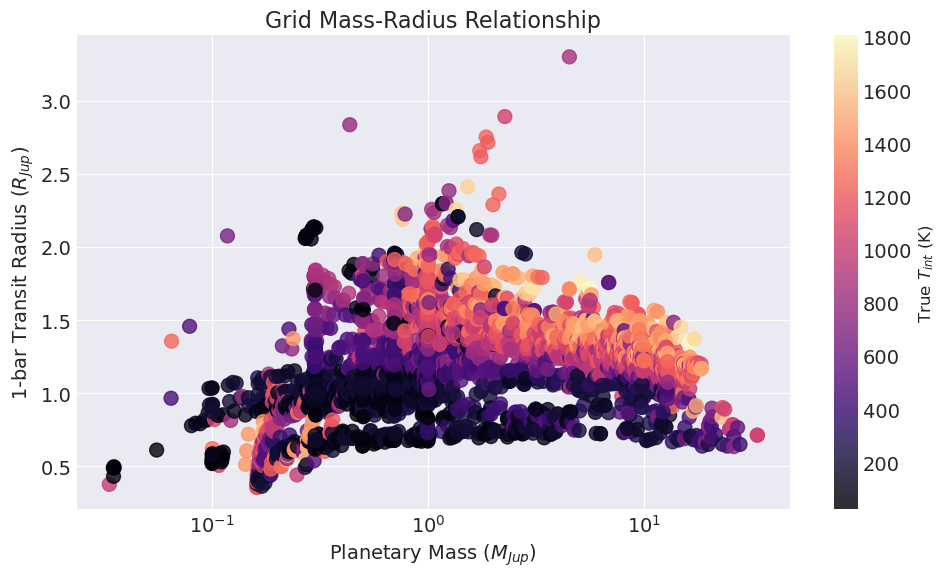

In [6]:
# Filter out crashed runs, but keep all physically valid planets!
valid_models = catalog[catalog['qc_status'].isin(['VALID'])].copy()

fig, ax = plt.subplots(figsize=(10, 6))

# Create a scatter plot using the TRUE 1-bar radius, colored by measured T_int
scatter = ax.scatter(
    valid_models['true_mass_Mjup'], 
    valid_models['R_1bar_Rjup'],      
    c=valid_models['T_int_true_K'], 
    cmap='magma', 
    s=100, 
    edgecolor=None,
    alpha=0.8
)

ax.set_xlabel(r"Planetary Mass ($M_{Jup}$)", fontsize=14)
ax.set_ylabel(r"1-bar Transit Radius ($R_{Jup}$)", fontsize=14)
ax.set_title("Grid Mass-Radius Relationship", fontsize=16)
ax.set_xscale('log')

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(r"True $T_{int}$ (K)", fontsize=12)

plt.tight_layout()
plt.show()


❌ Nothing was plotted. Please check the warnings above!


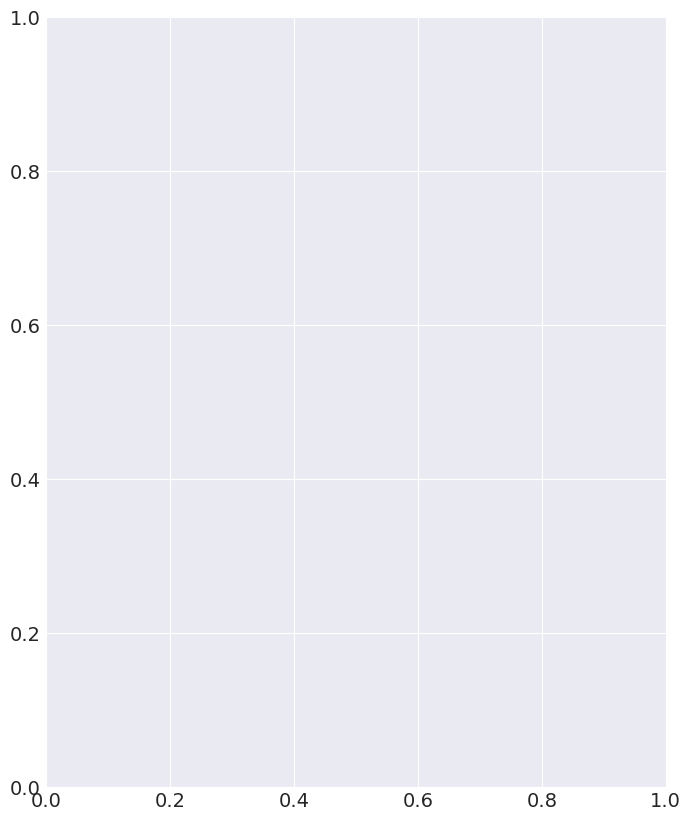

In [7]:
fig, ax = plt.subplots(figsize=(8, 10))

target_mass = 1
target_met = 0.0
target_Tint = 50
target_Tirr = 100

family_matches = catalog[
    (catalog['qc_status'].isin(['VALID'])) &
    (np.isclose(catalog['target_mass_Mjup'], target_mass, atol=0.5)) &
    (np.isclose(catalog['metallicity'], target_met, atol=2)) &
    (np.isclose(catalog['T_int_true_K'], target_Tint, atol=50)) &
    (np.isclose(catalog['T_irr_K'], target_Tirr, atol=50))
].copy()

# Open the HDF5 binary store in read-only mode
with h5py.File(DATA_PATH, "r") as h5f:
    
    plotted_any = False
    
    for index, row in family_matches.iterrows():
        model_id = row['model_id']
        t_int = row['T_int_true_K']
        
        # 1. Make sure the model ID exists
        if model_id not in h5f:
            continue
            
        model_grp = h5f[model_id]
        
        # 2. Smartly detect whether the folder is named 'profile' or 'stitched_profile'
        if 'profile' in model_grp:
            prof_name = 'profile'
        elif 'stitched_profile' in model_grp:
            prof_name = 'stitched_profile'
        else:
            print(f"⚠️ {model_id} has no profile folder. I see: {list(model_grp.keys())}")
            continue
            
        # 3. Dynamically find the Pressure and Temperature keys inside that folder
        available_columns = list(model_grp[prof_name].keys())
        p_keys = [k for k in available_columns if 'press' in k.lower()]
        t_keys = [k for k in available_columns if 'temp' in k.lower()]
        
        if not p_keys or not t_keys:
            print(f"⚠️ {model_id} missing P/T arrays. I see: {available_columns}")
            continue
            
        # 4. Extract the arrays using the auto-detected folder and column names
        pressure = model_grp[f"{prof_name}/{p_keys[0]}"][:]
        temperature = model_grp[f"{prof_name}/{t_keys[0]}"][:]
        
        # Auto-convert Pressure to Bar if it was saved in Pascals (values > 10,000)
        if pressure.max() > 1e4:
            pressure = pressure / 1e5
            
        # Plot them!
        ax.plot(temperature, pressure, lw=2.5, label=f"$T_{{int}}$ = {t_int:.0f} K")
        plotted_any = True

if plotted_any:
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (K)", fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title(r"Continuous $1.0\ M_{Jup}$ T-P Profiles", fontsize=16)
    ax.set_xscale('log')
    
    # Only show legend if there aren't too many lines
    if len(family_matches) <= 15:
        ax.legend(loc="upper right")
        
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("\n❌ Nothing was plotted. Please check the warnings above!")

In [8]:
catalog

,model_id,status,target_mass_Mjup,R_1bar_Rjup,true_mass_Mjup,T_int_dial_K,T_int_true_K,T_irr_K,metallicity,core_mass_Me,...,GAIA_GAIA3.G_flux_Wm2um,GAIA_GAIA3.G_flux_Jy,GAIA_GAIA3.Gbp_flux_Wm2um,GAIA_GAIA3.Gbp_flux_Jy,GAIA_GAIA3.Grp_flux_Wm2um,GAIA_GAIA3.Grp_flux_Jy,TESS_TESS.Red_flux_Wm2um,TESS_TESS.Red_flux_Jy,Kepler_Kepler.K_flux_Wm2um,Kepler_Kepler.K_flux_Jy
0,model_00000,crashed,0.100000,NaN,NaN,100.000000,100.000000,500.000000,0.000000,10.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,model_00001,crashed,0.100000,NaN,NaN,100.000000,100.000000,500.000000,1.000000,10.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,model_00002,crashed,0.300000,NaN,NaN,200.000000,200.000000,500.000000,1.000000,10.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,model_00003,crashed,1.000000,NaN,NaN,500.000000,500.000000,100.000000,-1.000000,50.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,model_00004,crashed,1.000000,NaN,NaN,200.000000,200.000000,1000.000000,0.000000,50.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6618,model_06618,target_reached,9.906524,1.152048,9.911568,1096.042981,996.433011,692.336212,-1.962674,25.421208,...,13115.347349,1.786659e+15,1324.275119,1.186693e+14,33429.028470,6.827760e+15,46455.280848,9.848912e+15,6164.239441,8.466464e+14
6619,model_06619,target_reached,9.920646,1.326414,9.941976,1355.030181,1317.827814,288.035054,0.666743,62.714577,...,9015.542864,1.228157e+15,668.345953,5.989099e+13,23846.969276,4.870658e+15,37832.312821,8.020770e+15,3747.015096,5.146453e+14
6620,model_06620,target_reached,9.971201,1.220967,10.016202,1507.552864,1255.406993,920.406171,-1.645581,49.275153,...,37023.943236,5.043645e+15,5315.310389,4.763090e+14,89548.160827,1.828989e+16,123331.235556,2.614726e+16,19796.485889,2.719009e+15
6621,model_06621,target_reached,9.971201,1.223522,10.012707,1507.552864,1262.845795,920.406171,-1.645581,49.275153,...,38211.753856,5.205456e+15,5516.831776,4.943675e+14,92373.144782,1.886689e+16,127253.772367,2.697887e+16,20440.798487,2.807504e+15


✅ Found 45 models for the Mass=0.5, Met=0.0 family!


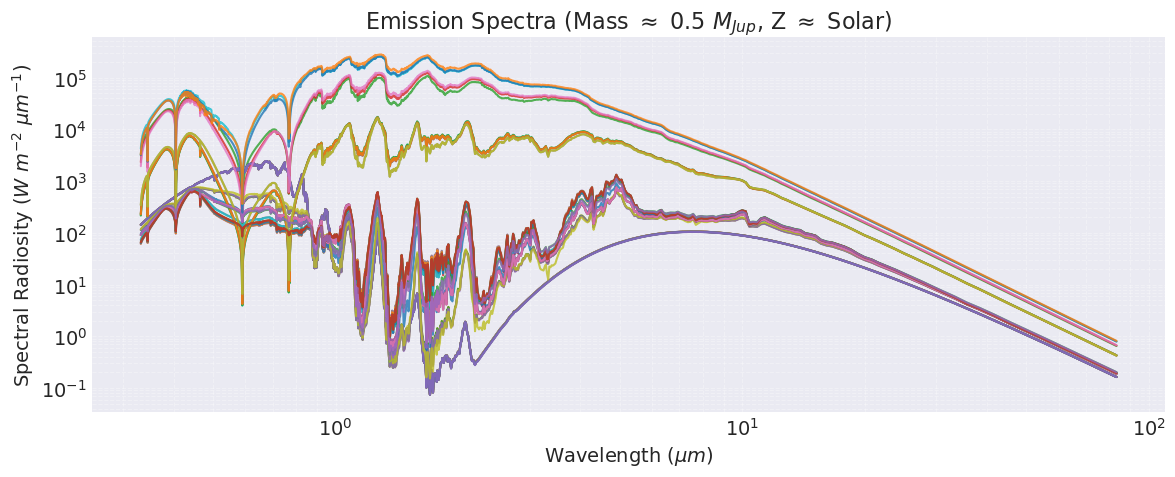

In [9]:
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np

# --- 2. Define the 'family_matches' Filter ---
# Example: Let's isolate all successful runs for a 1.0 M_Jup planet at Solar Metallicity (0.0)
target_mass = 0.5
target_met = 0.0
target_Tint = 50

family_matches = catalog[
    (catalog['qc_status'].isin(['VALID'])) &
    (np.isclose(catalog['target_mass_Mjup'], target_mass, atol=0.5)) &
    (np.isclose(catalog['metallicity'], target_met, atol=0.2)) &
    (np.isclose(catalog['T_int_true_K'], target_Tint, atol=50))
].copy()

# Sort them by T_int so the legend looks clean
family_matches = family_matches.sort_values(by='T_int_true_K')

print(f"✅ Found {len(family_matches)} models for the Mass={target_mass}, Met={target_met} family!")

# --- 3. The Plotting Routine ---
fig, ax = plt.subplots(figsize=(12, 5))

with h5py.File(DATA_PATH, "r") as h5f:
    
    plotted_any = False
    
    for index, row in family_matches.iterrows():
        model_id = row['model_id']
        t_int = row['T_int_true_K']
        
        try:
            # Note: We now look inside Folder 5!
            phot_grp = h5f[f"{model_id}/photometry"]
            
            # Extract Wavelength and Flux 
            wavelength = phot_grp["wavelength_um"][:]
            flux = phot_grp["emission_flux_W_m2_um"][:]
            
            # Sort for clean plotting
            idx = np.argsort(wavelength)
            
            ax.plot(wavelength[idx], flux[idx], lw=1.5, alpha=0.8, label=f"$T_{{int}}$ = {t_int:.0f} K")
            plotted_any = True
            
        except KeyError:
            print(f"⚠️ Model {model_id} does not contain spectral arrays inside the photometry folder.")

if plotted_any:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"Wavelength ($\mu m$)", fontsize=14)
    ax.set_ylabel(r"Spectral Radiosity ($W\ m^{-2}\ \mu m^{-1}$)", fontsize=14)
    ax.set_title(f"Emission Spectra (Mass $\\approx$ {target_mass} $M_{{Jup}}$, Z $\\approx$ Solar)", fontsize=16)
    
    # Only show legend if the plot isn't too crowded
    if len(family_matches) <= 15:
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("❌ No spectra were plotted.")

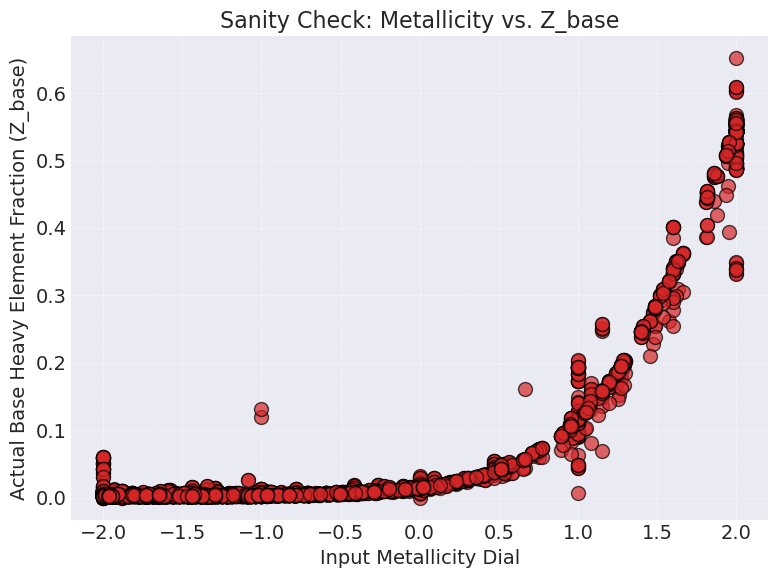

In [10]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# Filter for all valid models
valid_models = catalog[catalog['qc_status'].isin(['VALID'])].copy()

z_base_values = []
metallicity_values = []

# Open the HDF5 file to extract the exact z_base used for each model
with h5py.File(DATA_PATH, "r") as h5f:
    for index, row in valid_models.iterrows():
        model_id = row['model_id']
        met = row['metallicity']
        
        try:
            # Safely grab z_base from the parameters attributes
            z_base = h5f[f"{model_id}/parameters"].attrs.get('z_base', np.nan)
        except KeyError:
            z_base = np.nan
            
        z_base_values.append(z_base)
        metallicity_values.append(met)

# Add it to our dataframe for plotting
valid_models['z_base'] = z_base_values

# Now let's plot it to see if the dial actually moved!
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    valid_models['metallicity'], 
    valid_models['z_base'], 
    c='tab:red', 
    s=100, 
    edgecolor='black',
    alpha=0.7
)

ax.set_xlabel("Input Metallicity Dial", fontsize=14)
ax.set_ylabel("Actual Base Heavy Element Fraction (Z_base)", fontsize=14)
ax.set_title("Sanity Check: Metallicity vs. Z_base", fontsize=16)

plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
with h5py.File(DATA_PATH, "r") as h5f:
    for model_id in h5f.keys():
            params = h5f[f"{model_id}/parameters"].attrs
            int_attrs = h5f[f"{model_id}/interior_raw"].attrs
            print(np.max(h5f[f"{model_id}/interior_raw/S"][:]))

72424.4248304493
55038.14853280036
55617.36185469853
55608.13829011146
55602.161966917694
55621.00817883272
55568.26477513624
65843.21001315204
74868.04045960377
67731.69155775965
54997.57780810812
54620.275052101904
54709.319183638276
55250.28050587926
55313.496732027226
56832.75096656232
56911.16320535468
58273.20829639439
58271.5743740018
56833.61616273192
28459.559371944524
24644.68397853276
80062.61444539008
25383.7762019872
26626.351894568652
28324.417706159948
56907.48765054019
79803.9281911761
55712.4026426136
71868.51781441047
28326.600495329498
24667.99561480071
25422.317061929578
26646.047588427566
55330.836974501
28463.089955897292
72821.16251160757
56942.6134042702
59203.1478466063
71771.14746686874
61309.764765446846
55742.720207470105
61190.86141205764
59626.49332854159
71772.29944386844
51292.68681113598
77659.16742420162
77408.55316186722
56826.44542863776
77408.78118151074
59031.75456240161
56832.183218848615
52328.74902334319
72064.04169158274
72764.82917106427
74181

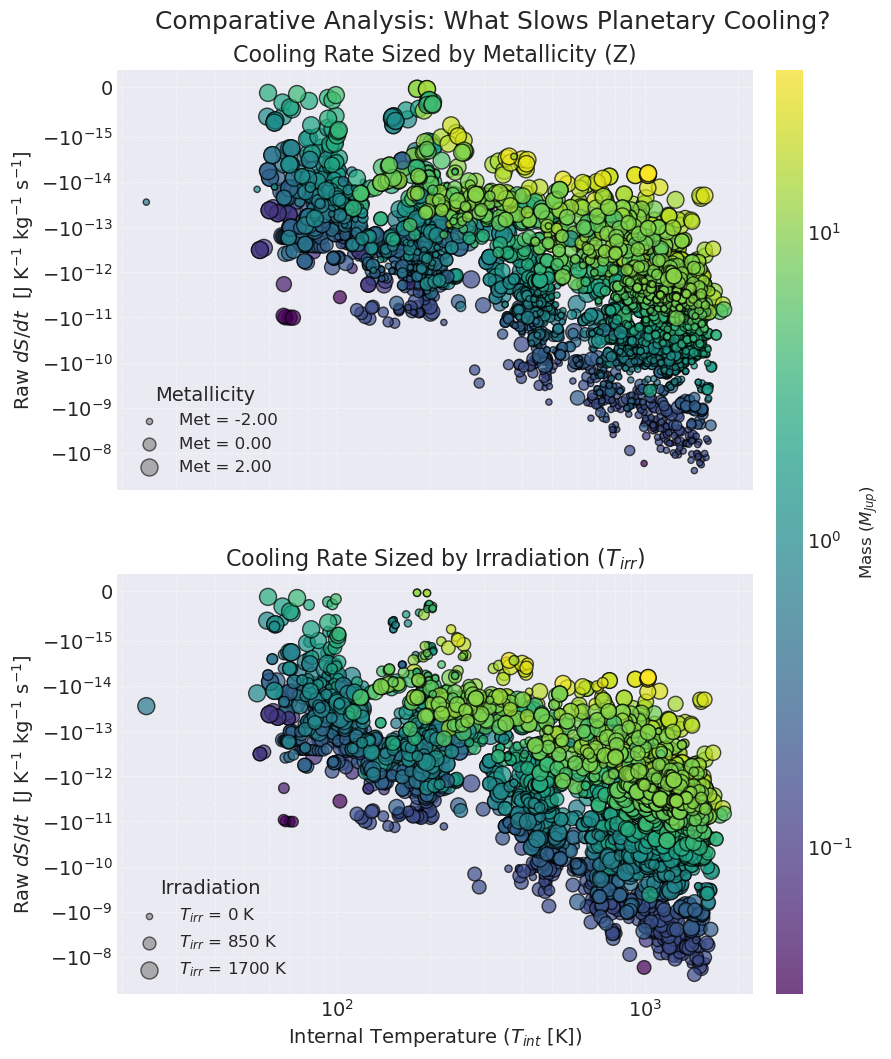

In [12]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm  # <-- 1. Import LogNorm

DATA_PATH = "../outputs/master_grid_data.h5"

rows = []

# 1. Extract all needed properties in a single pass
with h5py.File(DATA_PATH, "r") as h5f:
    for model_id in h5f.keys():
        try:
            params = h5f[f"{model_id}/parameters"].attrs
            int_attrs = h5f[f"{model_id}/interior_raw"].attrs
            
            t_int = params.get("T_int", np.nan)
            mass = params.get("true_mass_Mjup", params.get("mass", np.nan))
            met = params.get("Met", np.nan)
            t_irr = params.get("T_irr", np.nan)
            
            # Raw interior output (seconds per J/K/kg)
            dt_ds_raw = int_attrs.get("dt_ds_total", np.nan)
            S = np.max(h5f[f"{model_id}/interior_raw/S"][:])
            
            # Convert to physical cooling rate (J/K/kg per second)
            dsdt = 1.0 / dt_ds_raw if (pd.notna(dt_ds_raw) and dt_ds_raw != 0) else np.nan
            
            rows.append({
                "model_id": model_id,
                "mass_Mjup": mass,
                "T_int": t_int,
                "Met": met,
                "T_irr": t_irr,
                "dsdt": dsdt,
                "s" : S
            })
        except KeyError:
            continue

diag_df = pd.DataFrame(rows).dropna()

# --- Dynamic Size Mapping ---
# Metallicity Sizing
met_min, met_max = diag_df['Met'].min(), diag_df['Met'].max()
met_range = (met_max - met_min) if met_max != met_min else 1.0
if met_max == met_min:
    sizes_met = np.full(len(diag_df), 60)
else:
    sizes_met = 20 + 130 * ((diag_df['Met'] - met_min) / met_range)

# Irradiation Sizing
tirr_min, tirr_max = diag_df['T_irr'].min(), diag_df['T_irr'].max()
tirr_range = (tirr_max - tirr_min) if tirr_max != tirr_min else 1.0
if tirr_max == tirr_min:
    sizes_tirr = np.full(len(diag_df), 60)
else:
    sizes_tirr = 20 + 130 * ((diag_df['T_irr'] - tirr_min) / tirr_range)

# 2. Setup the Two-Panel Figure (Stacked Vertically)
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True, sharey=True)

# --- PANEL 1: Metallicity (Top) ---
scatter1 = axes[0].scatter(
    diag_df['T_int'], diag_df['dsdt'],  
    c=diag_df['mass_Mjup'], cmap='viridis', 
    norm=LogNorm(),  # <-- 2. Apply LogNorm here
    alpha=0.7, edgecolor='k', s=sizes_met
)
axes[0].set_ylabel(r"Raw $dS/dt$  [J K$^{-1}$ kg$^{-1}$ s$^{-1}$]", fontsize=14)
axes[0].set_title("Cooling Rate Sized by Metallicity (Z)", fontsize=16)
axes[0].set_yscale('symlog', linthresh=1e-15)
axes[0].grid(True, which="both", ls="--", alpha=0.4)

# Legend for Panel 1
if met_max != met_min:
    legend_met_vals = [met_min, (met_min + met_max) / 2, met_max]
    for val in legend_met_vals:
        dummy_size = 20 + 130 * ((val - met_min) / met_range)
        axes[0].scatter([], [], c='gray', alpha=0.6, s=dummy_size, 
                        label=f"Met = {val:.2f}", edgecolor='k')
    axes[0].legend(title="Metallicity", loc="best", framealpha=0.9)

# --- PANEL 2: Irradiation (Bottom) ---
scatter2 = axes[1].scatter(
    diag_df['T_int'], diag_df['dsdt'],  
    c=diag_df['mass_Mjup'], cmap='viridis', 
    norm=LogNorm(),  # <-- 3. Apply LogNorm here too
    alpha=0.7, edgecolor='k', s=sizes_tirr
)
axes[1].set_xlabel(r"Internal Temperature ($T_{int}$ [K])", fontsize=14)
axes[1].set_ylabel(r"Raw $dS/dt$  [J K$^{-1}$ kg$^{-1}$ s$^{-1}$]", fontsize=14)
axes[1].set_title("Cooling Rate Sized by Irradiation ($T_{irr}$)", fontsize=16)
axes[1].set_yscale('symlog', linthresh=1e-15)
axes[1].grid(True, which="both", ls="--", alpha=0.4)

axes[1].set_xscale('log')

# Legend for Panel 2
if tirr_max != tirr_min:
    legend_tirr_vals = [tirr_min, (tirr_min + tirr_max) / 2, tirr_max]
    for val in legend_tirr_vals:
        dummy_size = 20 + 130 * ((val - tirr_min) / tirr_range)
        axes[1].scatter([], [], c='gray', alpha=0.6, s=dummy_size, 
                        label=f"$T_{{irr}}$ = {val:.0f} K", edgecolor='k')
    axes[1].legend(title="Irradiation", loc="best", framealpha=0.9)
else:
    axes[1].scatter([], [], c='gray', alpha=0.6, s=60, label=f"All $T_{{irr}}$ = {tirr_min:.0f} K", edgecolor='k')
    axes[1].legend(title="Irradiation", loc="best", framealpha=0.9)

# --- Global Adjustments ---
# The colorbar will now automatically be log-scaled because of scatter2's norm
cbar = fig.colorbar(scatter2, ax=axes, pad=0.03, aspect=35)
cbar.set_label(r"Mass ($M_{Jup}$)", fontsize=12)

plt.suptitle("Comparative Analysis: What Slows Planetary Cooling?", fontsize=18, y=0.93)

plt.show()

In [13]:
diag_df

,model_id,mass_Mjup,T_int,Met,T_irr,dsdt,s
0,model_00011,0.033298,993.095689,-2.000000,1000.000000,-1.719317e-08,72424.424830
1,model_00012,0.034819,102.155749,0.000000,1000.000000,-3.568854e-12,55038.148533
2,model_00013,0.034767,70.185434,1.000000,500.000000,-1.012757e-11,55617.361855
3,model_00014,0.034830,67.968031,1.000000,500.000000,-9.980939e-12,55608.138290
4,model_00015,0.035035,67.053160,1.000000,500.000000,-9.224945e-12,55602.161967
...,...,...,...,...,...,...,...
6516,model_06618,9.911568,996.433011,-1.962674,692.336212,-1.571525e-12,65918.395383
6517,model_06619,9.941976,1317.827814,0.666743,288.035054,-2.024548e-13,71467.025723
6518,model_06620,10.016202,1255.406993,-1.645581,920.406171,-3.426460e-12,69542.909402
6519,model_06621,10.012707,1262.845795,-1.645581,920.406171,-3.524124e-12,69645.617988


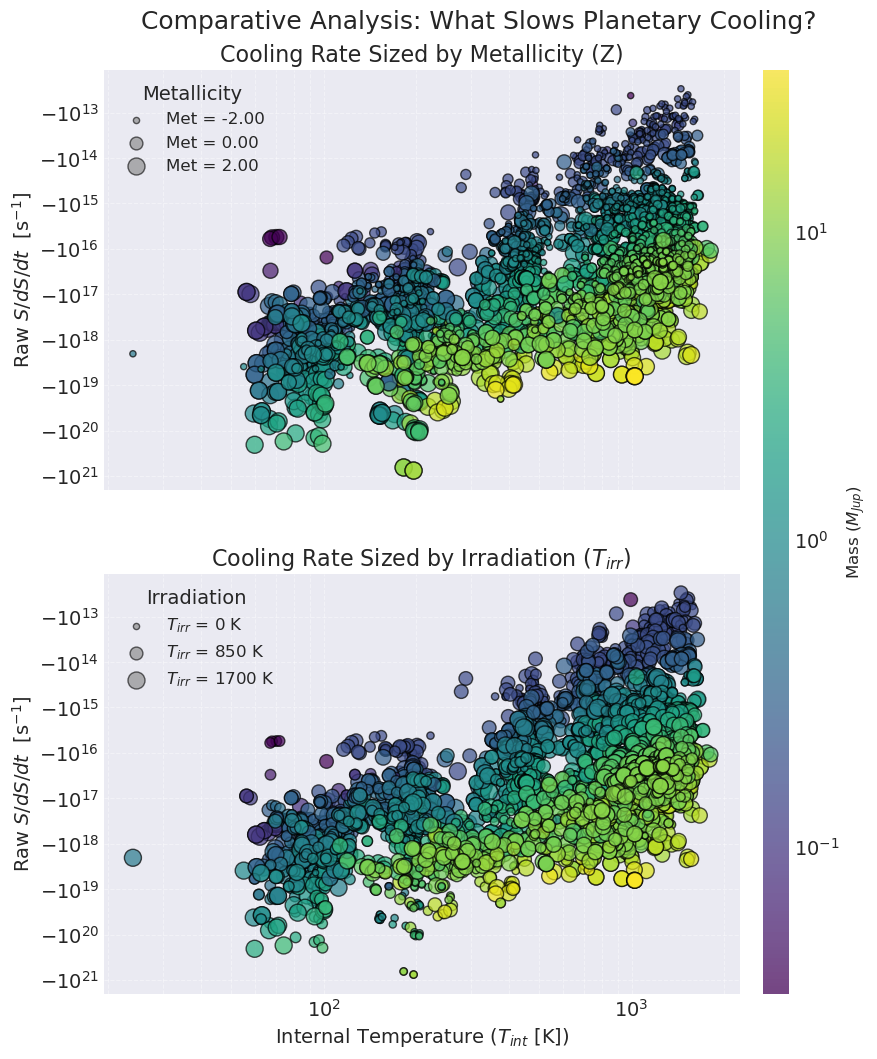

In [14]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm  # <-- 1. Import LogNorm

DATA_PATH = "../outputs/master_grid_data.h5"

rows = []

# 1. Extract all needed properties in a single pass
with h5py.File(DATA_PATH, "r") as h5f:
    for model_id in h5f.keys():
        try:
            params = h5f[f"{model_id}/parameters"].attrs
            int_attrs = h5f[f"{model_id}/interior_raw"].attrs
            
            t_int = params.get("T_int", np.nan)
            mass = params.get("true_mass_Mjup", params.get("mass", np.nan))
            met = params.get("Met", np.nan)
            t_irr = params.get("T_irr", np.nan)
            
            # Raw interior output (seconds per J/K/kg)
            dt_ds_raw = int_attrs.get("dt_ds_total", np.nan)
            S = np.max(h5f[f"{model_id}/interior_raw/S"][:])
            
            # Convert to physical cooling rate (J/K/kg per second)
            dsdt = 1.0 / dt_ds_raw if (pd.notna(dt_ds_raw) and dt_ds_raw != 0) else np.nan
            
            rows.append({
                "model_id": model_id,
                "mass_Mjup": mass,
                "T_int": t_int,
                "Met": met,
                "T_irr": t_irr,
                "dsdt": dsdt,
                "S" : S
            })
        except KeyError:
            continue

diag_df = pd.DataFrame(rows).dropna()

# --- Dynamic Size Mapping ---
# Metallicity Sizing
met_min, met_max = diag_df['Met'].min(), diag_df['Met'].max()
met_range = (met_max - met_min) if met_max != met_min else 1.0
if met_max == met_min:
    sizes_met = np.full(len(diag_df), 60)
else:
    sizes_met = 20 + 130 * ((diag_df['Met'] - met_min) / met_range)

# Irradiation Sizing
tirr_min, tirr_max = diag_df['T_irr'].min(), diag_df['T_irr'].max()
tirr_range = (tirr_max - tirr_min) if tirr_max != tirr_min else 1.0
if tirr_max == tirr_min:
    sizes_tirr = np.full(len(diag_df), 60)
else:
    sizes_tirr = 20 + 130 * ((diag_df['T_irr'] - tirr_min) / tirr_range)

# 2. Setup the Two-Panel Figure (Stacked Vertically)
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True, sharey=True)

# --- PANEL 1: Metallicity (Top) ---
scatter1 = axes[0].scatter(
    diag_df['T_int'], diag_df['S']/diag_df['dsdt'],  
    c=diag_df['mass_Mjup'], cmap='viridis', 
    norm=LogNorm(),  # <-- 2. Apply LogNorm here
    alpha=0.7, edgecolor='k', s=sizes_met
)
axes[0].set_ylabel(r"Raw $S/dS/dt$  [s$^{-1}$]", fontsize=14)
axes[0].set_title("Cooling Rate Sized by Metallicity (Z)", fontsize=16)
axes[0].set_yscale('symlog', linthresh=1e-15)
axes[0].grid(True, which="both", ls="--", alpha=0.4)

# Legend for Panel 1
if met_max != met_min:
    legend_met_vals = [met_min, (met_min + met_max) / 2, met_max]
    for val in legend_met_vals:
        dummy_size = 20 + 130 * ((val - met_min) / met_range)
        axes[0].scatter([], [], c='gray', alpha=0.6, s=dummy_size, 
                        label=f"Met = {val:.2f}", edgecolor='k')
    axes[0].legend(title="Metallicity", loc="best", framealpha=0.9)

# --- PANEL 2: Irradiation (Bottom) ---
scatter2 = axes[1].scatter(
    diag_df['T_int'], diag_df['S']/diag_df['dsdt'],  
    c=diag_df['mass_Mjup'], cmap='viridis', 
    norm=LogNorm(),  # <-- 3. Apply LogNorm here too
    alpha=0.7, edgecolor='k', s=sizes_tirr
)
axes[1].set_xlabel(r"Internal Temperature ($T_{int}$ [K])", fontsize=14)
axes[1].set_ylabel(r"Raw $S/dS/dt$  [s$^{-1}$]", fontsize=14)
axes[1].set_title("Cooling Rate Sized by Irradiation ($T_{irr}$)", fontsize=16)
axes[1].set_yscale('symlog', linthresh=1e-15)
axes[1].grid(True, which="both", ls="--", alpha=0.4)

axes[1].set_xscale('log')

# Legend for Panel 2
if tirr_max != tirr_min:
    legend_tirr_vals = [tirr_min, (tirr_min + tirr_max) / 2, tirr_max]
    for val in legend_tirr_vals:
        dummy_size = 20 + 130 * ((val - tirr_min) / tirr_range)
        axes[1].scatter([], [], c='gray', alpha=0.6, s=dummy_size, 
                        label=f"$T_{{irr}}$ = {val:.0f} K", edgecolor='k')
    axes[1].legend(title="Irradiation", loc="best", framealpha=0.9)
else:
    axes[1].scatter([], [], c='gray', alpha=0.6, s=60, label=f"All $T_{{irr}}$ = {tirr_min:.0f} K", edgecolor='k')
    axes[1].legend(title="Irradiation", loc="best", framealpha=0.9)

# --- Global Adjustments ---
# The colorbar will now automatically be log-scaled because of scatter2's norm
cbar = fig.colorbar(scatter2, ax=axes, pad=0.03, aspect=35)
cbar.set_label(r"Mass ($M_{Jup}$)", fontsize=12)

plt.suptitle("Comparative Analysis: What Slows Planetary Cooling?", fontsize=18, y=0.93)

plt.show()

Total models: 6521 | Solar Metallicity models: 460


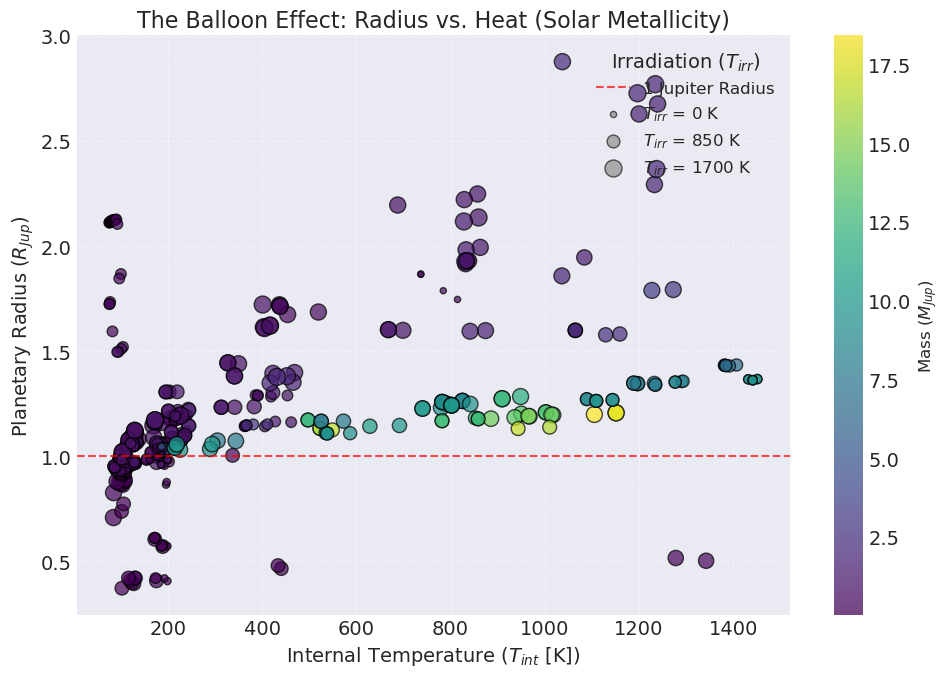

In [15]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../outputs/master_grid_data.h5"

# Constants for conversion
G = 6.67430e-11        # Gravitational constant (m^3 kg^-1 s^-2)
M_JUP_KG = 1.898e27    # Jupiter mass in kg
R_JUP_M = 7.1492e7     # Jupiter equatorial radius in meters

rows = []

# 1. Extract data including Metallicity
with h5py.File(DATA_PATH, "r") as h5f:
    for model_id in h5f.keys():
        try:
            params = h5f[f"{model_id}/parameters"].attrs
            
            t_int = params.get("T_int", np.nan)
            mass = params.get("true_mass_Mjup", params.get("mass", np.nan))
            t_irr = params.get("T_irr", np.nan)
            met = params.get("Met", np.nan)
            g_1bar = params.get("g_1bar", np.nan)
            
            if pd.notna(mass) and pd.notna(g_1bar) and g_1bar > 0 and pd.notna(met):
                mass_kg = mass * M_JUP_KG
                radius_m = np.sqrt((G * mass_kg) / g_1bar)
                radius_rjup = radius_m / R_JUP_M
                
                rows.append({
                    "model_id": model_id,
                    "mass_Mjup": mass,
                    "T_int": t_int,
                    "T_irr": t_irr,
                    "Met": met,
                    "Radius_Rjup": radius_rjup
                })
        except KeyError:
            continue

raw_df = pd.DataFrame(rows).dropna()

# --- NEW: Filter for Solar Metallicity ---
# We keep only models where Met is approximately 0.0 (Solar)
solar_df = raw_df[np.abs(raw_df['Met']) <= 0.1].copy()

print(f"Total models: {len(raw_df)} | Solar Metallicity models: {len(solar_df)}")

if solar_df.empty:
    print("⚠️ No models found near solar metallicity (Met ~ 0.0).")
else:
    # --- Dynamic Size Mapping for T_irr ---
    tirr_min = solar_df['T_irr'].min()
    tirr_max = solar_df['T_irr'].max()
    tirr_range = (tirr_max - tirr_min) if tirr_max != tirr_min else 1.0

    if tirr_max == tirr_min:
        sizes_tirr = np.full(len(solar_df), 60)
    else:
        sizes_tirr = 20 + 130 * ((solar_df['T_irr'] - tirr_min) / tirr_range)

    # 2. Plot Radius vs. T_int
    fig, ax = plt.subplots(figsize=(10, 7))

    scatter = ax.scatter(
        solar_df['T_int'], 
        solar_df['Radius_Rjup'],  
        c=solar_df['mass_Mjup'], 
        cmap='viridis', 
        alpha=0.7,
        edgecolor='k',
        s=sizes_tirr
    )

    ax.set_xlabel(r"Internal Temperature ($T_{int}$ [K])", fontsize=14)
    ax.set_ylabel(r"Planetary Radius ($R_{Jup}$)", fontsize=14)
    ax.set_title("The Balloon Effect: Radius vs. Heat (Solar Metallicity)", fontsize=16)

    # Add a reference line for exactly 1 Jupiter Radius
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label="1 Jupiter Radius")

    # Colorbar for Mass
    cbar = plt.colorbar(scatter)
    cbar.set_label(r"Mass ($M_{Jup}$)", fontsize=12)

    # Legend for T_irr Sizes
    if tirr_max != tirr_min:
        legend_tirr_vals = [tirr_min, (tirr_min + tirr_max) / 2, tirr_max]
        for val in legend_tirr_vals:
            dummy_size = 20 + 130 * ((val - tirr_min) / tirr_range)
            ax.scatter([], [], c='gray', alpha=0.6, s=dummy_size, 
                       label=f"$T_{{irr}}$ = {val:.0f} K", edgecolor='k')
        ax.legend(title="Irradiation ($T_{irr}$)", loc="upper right", framealpha=0.9)
    else:
        ax.scatter([], [], c='gray', alpha=0.6, s=60, label=f"All $T_{{irr}}$ = {tirr_min:.0f} K", edgecolor='k')
        ax.legend(title="Irradiation", loc="upper right", framealpha=0.9)

    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

In [16]:
catalog.columns[:20]

Index(['model_id', 'status', 'target_mass_Mjup', 'R_1bar_Rjup',
       'true_mass_Mjup', 'T_int_dial_K', 'T_int_true_K', 'T_irr_K',
       'metallicity', 'core_mass_Me', 'f_sed', 'kzz', 'iterations',
       'P_link_bar', 'R_total_m', 'original_file', 'qc_status',
       'JWST_NIRCam.F070W_flux_Wm2um', 'JWST_NIRCam.F070W_flux_Jy',
       'JWST_NIRCam.F090W_flux_Wm2um'],
      dtype='object')

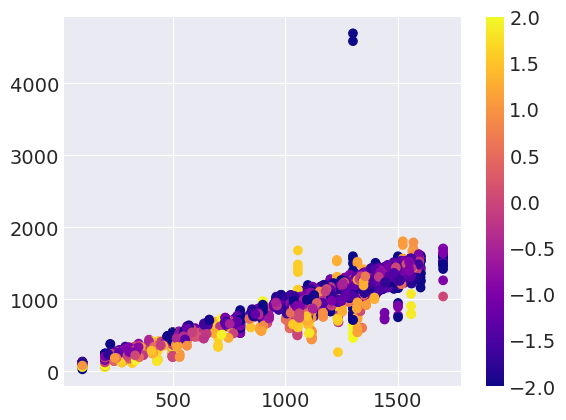

In [17]:
plt.scatter(catalog['T_int_dial_K'],catalog['T_int_true_K'], c=catalog['metallicity'],cmap='plasma')
plt.colorbar()

🔍 Found 2746 highly depleted outlier models out of 6521.


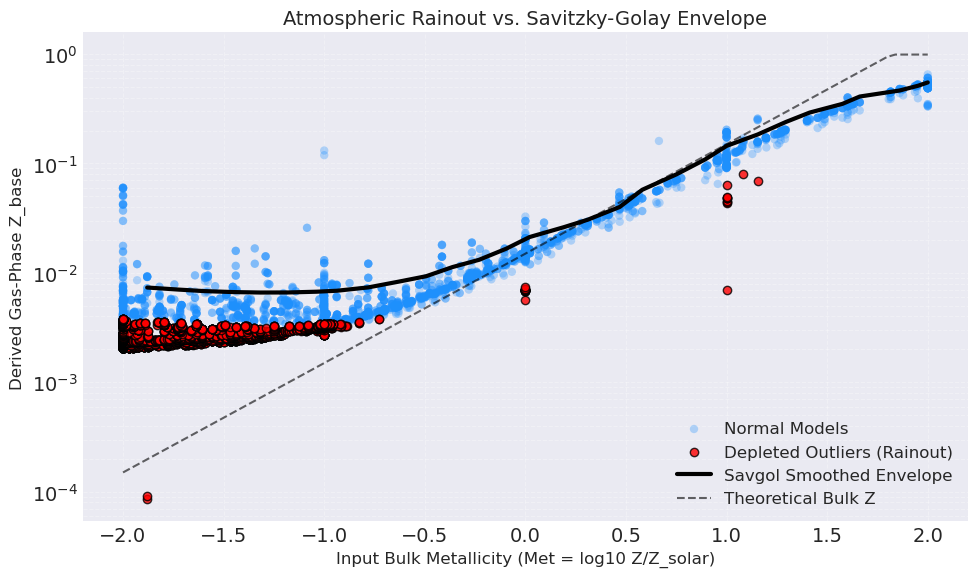


🚀 Extracting the most depleted model: model_00956
   Input Met  : -2.00
   Expected Z : 0.0076
   Actual Z   : 0.0000  <-- Massive depletion!
   T_int      : 701.1 K
   T_irr      : 1500.0 K


TypeError: Accessing a group is done with bytes or str, not <class 'slice'>

In [18]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

# Assuming you have your plotting tools available
from fuzzycore.plotting import plot_diagnostics

# 1. Path to your compiled master HDF5 file
h5_path = Path("../outputs/master_grid_data.h5")

# 2. Extract Met and z_base for all models
data_rows = []
with h5py.File(h5_path, "r") as h5f:
    for model_id in h5f.keys():
        params = h5f[model_id]['parameters'].attrs
        
        # Only grab models that successfully converged
        if 'interior_raw' in h5f[model_id]: 
            data_rows.append({
                'model_id': model_id,
                'Met': params.get('Met', np.nan),
                'z_base': params.get('z_base', np.nan),
                'T_int': params.get('T_int', np.nan),
                'T_irr': params.get('T_irr', np.nan)
            })

df_analysis = pd.DataFrame(data_rows).dropna()

# 3. Calculate the "Expected" Z_base (Theoretical scaling)
df_analysis['Expected_Z'] = np.clip(0.015 * (10 ** df_analysis['Met']), 0, 0.99)

# =====================================================================
# 3b. Empirical Trend Fitting (Savitzky-Golay Filter)
# =====================================================================
# Group into bins to find the 95th percentile (no-rainout ceiling)
bins = np.linspace(df_analysis['Met'].min(), df_analysis['Met'].max(), 30)
df_analysis['Met_bin'] = np.digitize(df_analysis['Met'], bins)

# Get the upper envelope and sort it to ensure the interpolator works
envelope = df_analysis.groupby('Met_bin')[['Met', 'z_base']].quantile(0.95).dropna().sort_values('Met')

# Determine a safe Savitzky-Golay window length (must be odd and <= len(data))
window = min(11, len(envelope))
if window % 2 == 0: 
    window -= 1

# Apply the Savitzky-Golay filter in log-space
smoothed_log_z = savgol_filter(np.log10(envelope['z_base']), window_length=window, polyorder=2)

# Create an interpolator from the smoothed envelope to map it back to all individual models
envelope_interp = interp1d(envelope['Met'], smoothed_log_z, kind='linear', fill_value="extrapolate")

# Evaluate the fit and ensure it mathematically cannot exceed Z=0.99
df_analysis['Fitted_Z'] = np.clip(10 ** envelope_interp(df_analysis['Met']), 0.0, 0.99)

# =====================================================================
# 4. Find the Outliers
# =====================================================================
# We define an outlier as a model that retains less than 50% of its expected gas-phase metals
df_analysis['Depletion_Ratio'] = df_analysis['z_base'] / df_analysis['Fitted_Z']
outliers = df_analysis[df_analysis['Depletion_Ratio'] < 0.5].sort_values('Depletion_Ratio')

print(f"🔍 Found {len(outliers)} highly depleted outlier models out of {len(df_analysis)}.")

# =====================================================================
# 5. Plot the Trend
# =====================================================================
plt.figure(figsize=(10, 6))

# Plot normal models
normal_models = df_analysis[df_analysis['Depletion_Ratio'] >= 0.5]
plt.scatter(normal_models['Met'], normal_models['z_base'], alpha=0.3, label="Normal Models", c='dodgerblue', edgecolors='none')

# Plot outliers
plt.scatter(outliers['Met'], outliers['z_base'], alpha=0.8, label="Depleted Outliers (Rainout)", c='red', edgecolors='k')

# Plot the Savitzky-Golay smoothed envelope
plt.plot(envelope['Met'], np.clip(10 ** smoothed_log_z, 0, 0.99), 'k-', lw=3, label="Savgol Smoothed Envelope")

# Plot theoretical line for reference
met_range_full = np.linspace(df_analysis['Met'].min(), df_analysis['Met'].max(), 100)
theoretical_curve = np.clip(0.015 * (10 ** met_range_full), 0, 0.99)
plt.plot(met_range_full, theoretical_curve, 'k--', lw=1.5, alpha=0.6, label="Theoretical Bulk Z")

plt.xlabel("Input Bulk Metallicity (Met = log10 Z/Z_solar)", fontsize=12)
plt.ylabel("Derived Gas-Phase Z_base", fontsize=12)
plt.title("Atmospheric Rainout vs. Savitzky-Golay Envelope", fontsize=14)
plt.yscale('log') 
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3, which="both", ls="--")
plt.tight_layout()
plt.show()

# =====================================================================
# 6. Extract and Plot the Worst Outlier
# =====================================================================
if not outliers.empty:
    worst_model = outliers.iloc[0]
    worst_model_id = worst_model['model_id']
    
    print(f"\n🚀 Extracting the most depleted model: {worst_model_id}")
    print(f"   Input Met  : {worst_model['Met']:.2f}")
    print(f"   Expected Z : {worst_model['Fitted_Z']:.4f}")
    print(f"   Actual Z   : {worst_model['z_base']:.4f}  <-- Massive depletion!")
    print(f"   T_int      : {worst_model['T_int']:.1f} K")
    print(f"   T_irr      : {worst_model['T_irr']:.1f} K")
    
    with h5py.File(h5_path, "r") as h5f:
        target_grp = h5f[worst_model_id]
        
        interior_raw = {}
        for key in target_grp['interior_raw'].keys():
            interior_raw[key] = target_grp['interior_raw'][key][:]
        for key in target_grp['interior_raw'].attrs.keys():
            interior_raw[key] = target_grp['interior_raw'].attrs[key]
            
    print(f"\nGenerating diagnostic plot for {worst_model_id}...")
    plot_diagnostics(interior_raw, save_name=f"outlier_{worst_model_id}_diagnostics")

In [ ]:
import pickle
import numpy as np
from pathlib import Path
import os

# 1. Point this to the directory containing your converged models
grid_dir = Path("../outputs/grid_run/steps") 
pkl_files = list(grid_dir.glob("*.pkl"))

deleted_count = 0
total_count = len(pkl_files)

print(f"🔍 Scanning {total_count} planetary models for density inversions...")

for pkl_path in pkl_files:
    try:
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)
            
        # Extract the continuous stitched profile
        profile = data.get('profile', data.get('stitched_profile'))
        
        if profile is not None and not profile.empty:
            # Ensure it is perfectly sorted by pressure (lowest to highest)
            profile = profile.sort_values('Pressure_bar')
            rho = profile['Density_kgm3'].values
            
            # Calculate the change in density between each vertical layer
            d_rho = np.diff(rho)
            
            # Check for inversions. 
            # We use a tiny tolerance (-1e-3) to ensure we don't accidentally 
            # delete good models due to microscopic floating-point math noise.
            if np.any(d_rho < -1e-3):
                # Non-physical inversion detected! Delete the file.
                pkl_path.unlink()  
                deleted_count += 1
                
    except Exception as e:
        print(f"⚠️ Error reading {pkl_path.name}: {e}")

print("-" * 50)
print(f"✅ Cleanup complete!")
print(f"🗑️ Deleted {deleted_count} non-physical models.")
print(f"🌍 Retained {total_count - deleted_count} physically valid models.")

🔍 Scanning 6799 planetary models for density inversions...
--------------------------------------------------
✅ Cleanup complete!
🗑️ Deleted 4509 non-physical models.
🌍 Retained 2290 physically valid models.
